Code to show wide FOV ring tracking showing inertial wave tracking at high rotation rates.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


In [2]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM12']

u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()

u, v = oj.scaleVel(u, v, 60)
u, v = u*25, v*25
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

Time = oj.frames_to_seconds(u, v, 60)
vort, vort_gauss = oj.calculate_vorticity(u, v)

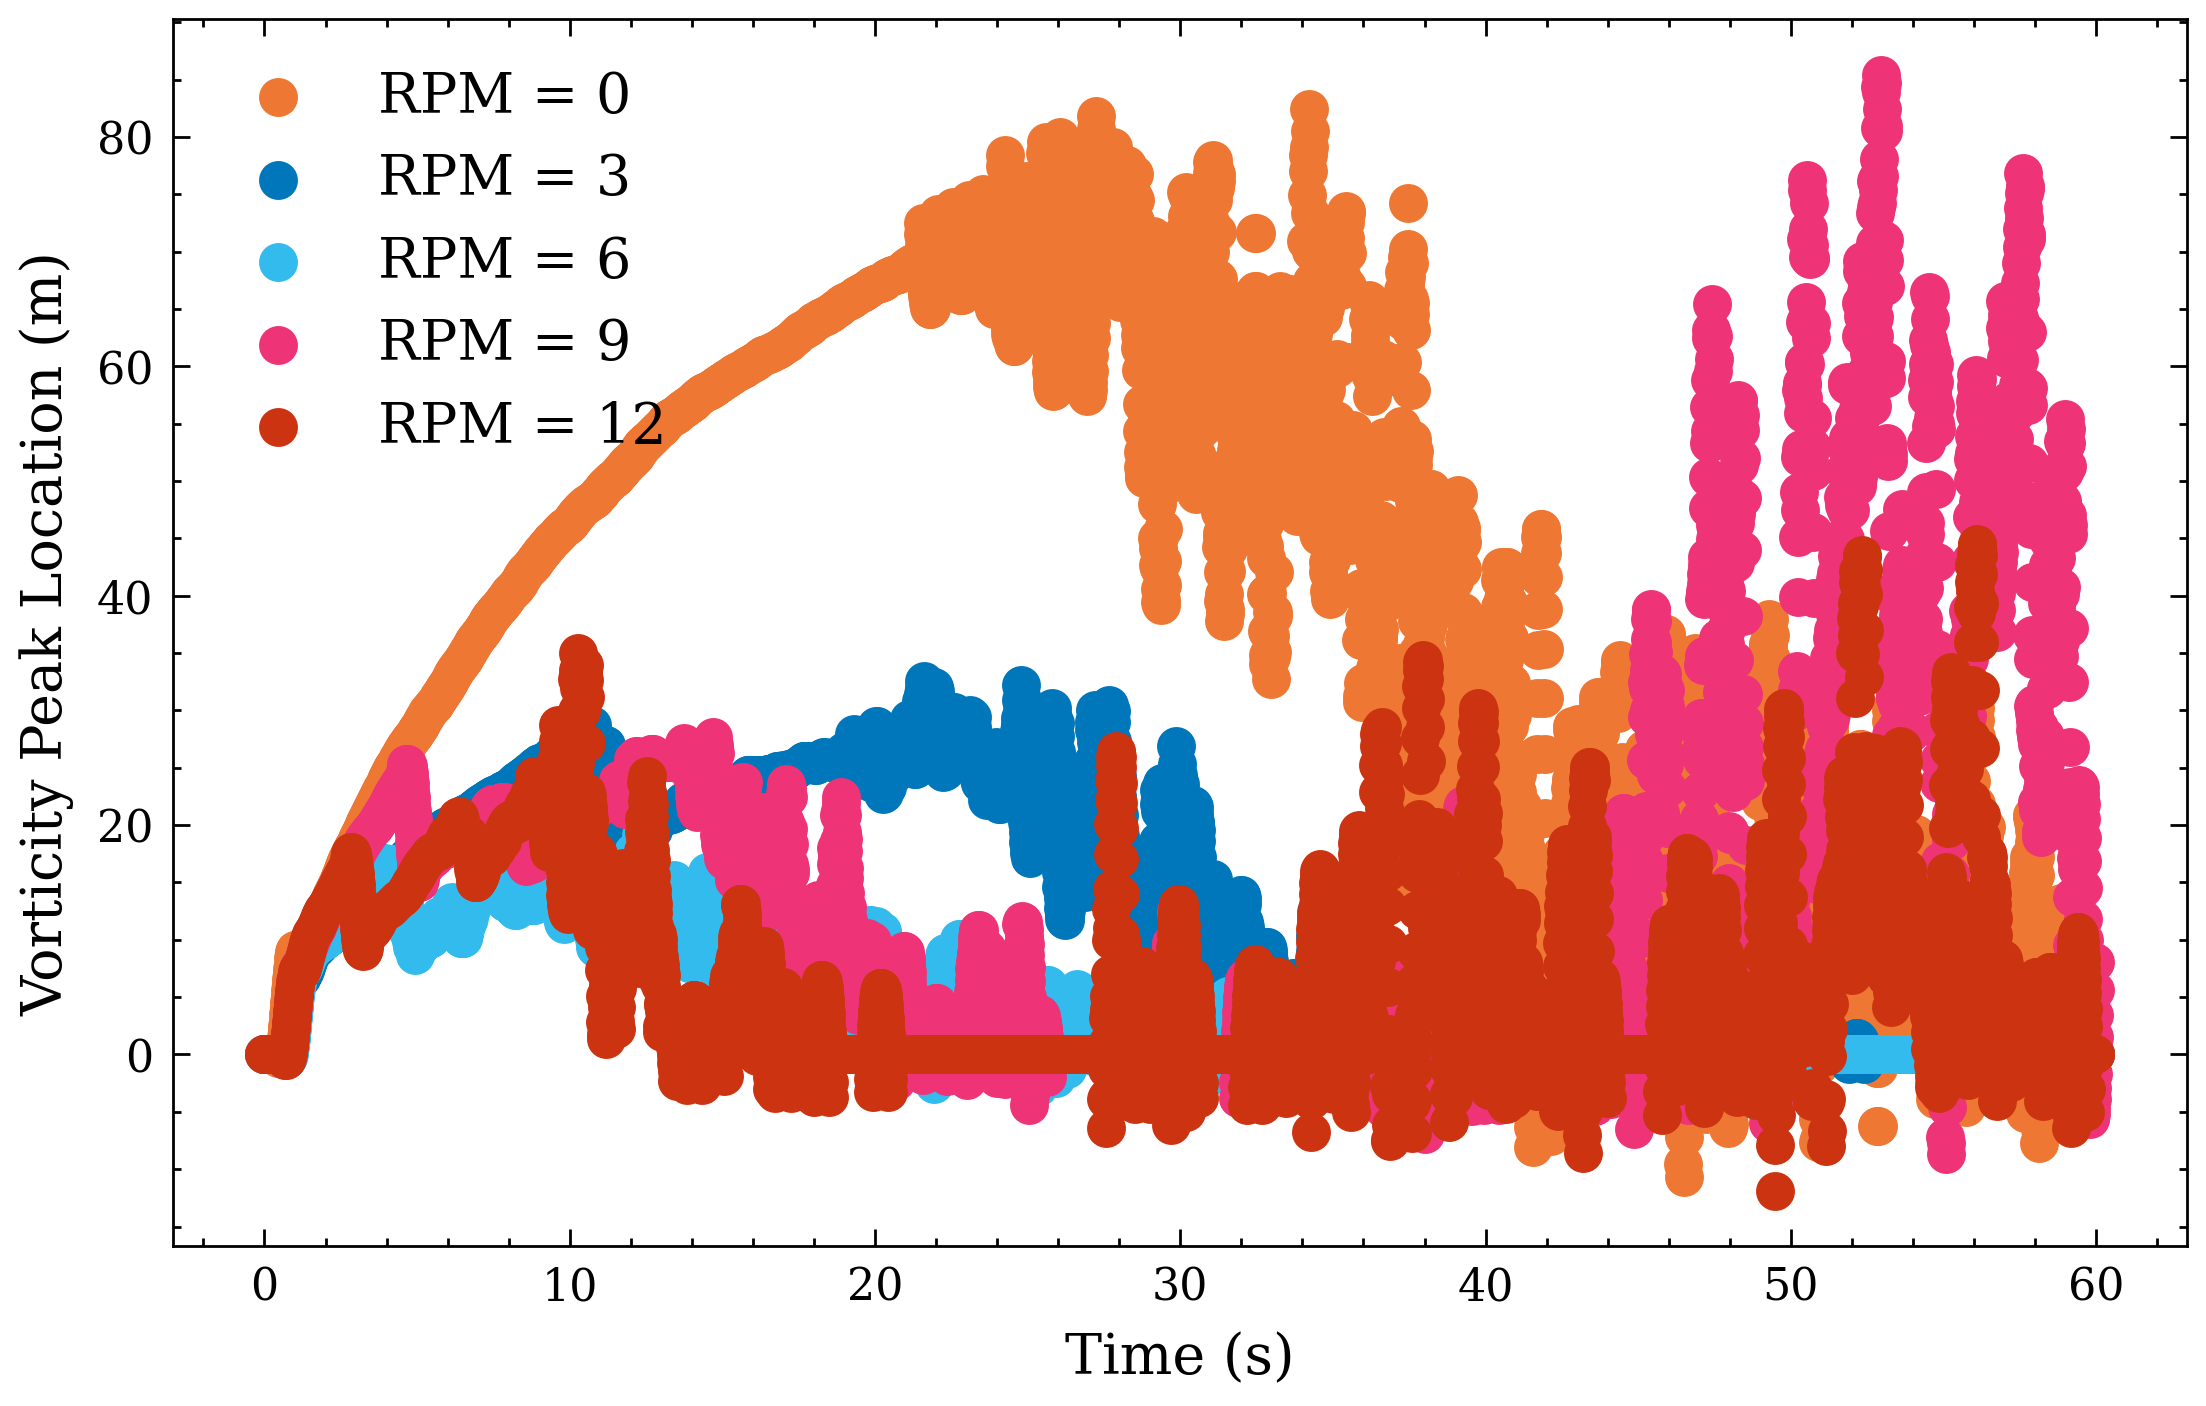

In [ ]:
h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
from scipy.signal import savgol_filter
rpms = [0,3,6,9,12]

fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

for i in range(len(rpms)):
    vels = h5file['Wide']['U200']['L100']['RPM{}'.format(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVel(u, v, 60)
    vortLocMax, vortLocMin = oj.vorticityPeakTracking_inter(u, v)
    # vortLocMax[:,1] = oj.FilterSpikes(vortLocMax[:,1], 10)
    vortLocMax[:,1] = savgol_filter(vortLocMax[:,1], 31, 2)
    ax.scatter(Time, vortLocMax[:,1], label='RPM = ' + str(rpms[i]))

ax.set_xlabel('Time (s)')
ax.set_ylabel('Vorticity Peak Location (m)')
ax.legend()

# VortLocMean = np.zeros((u.shape[0], len(rpms)))
# for i in range(len(rpms)):
#     vels = h5file['Wide']['U200']['L100']['RPM{}'.format(rpms[i])]
#     u = vels[:,:,:,0]
#     v = vels[:,:,:,1]
#     u, v = oj.scaleVel(u, v, 60)
#     vortLocMax, vortLocMin = oj.vorticityPeakTracking_inter(u, v)
#     VortLocMean[:,i] = np.mean((vortLocMax[:,1], vortLocMin[:,1]), axis=0)

# f2, ax2 = plt.subplots(1, 1, figsize=(5.5, 3.5))
# ax2.plot(Time, VortLocMean[:,0], label='RPM = 0')
# ax2.plot(Time, VortLocMean[:,1], label='RPM = 3')
# ax2.plot(Time, VortLocMean[:,2], label='RPM = 6')
# ax2.plot(Time, VortLocMean[:,3], label='RPM = 9')
# ax2.plot(Time, VortLocMean[:,4], label='RPM = 12')


doing it individually

In [22]:
VortLocMean = np.zeros((u.shape[0], len(rpms)))
for i in range(len(rpms)):
    vels = h5file['Wide']['U200']['L100']['RPM{}'.format(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u, v = oj.scaleVel(u, v, 60)
    vortLocMax, vortLocMin = oj.vorticityPeakTracking_inter(u, v)
    # vortLocMax[:,1] = savgol_filter(vortLocMax[:,1], 31, 2)
    # vortLocMin[:,1] = savgol_filter(vortLocMin[:,1], 31, 2)
    VortLocMean[:,i] = np.mean((vortLocMax[:,1], vortLocMin[:,1]), axis=0)

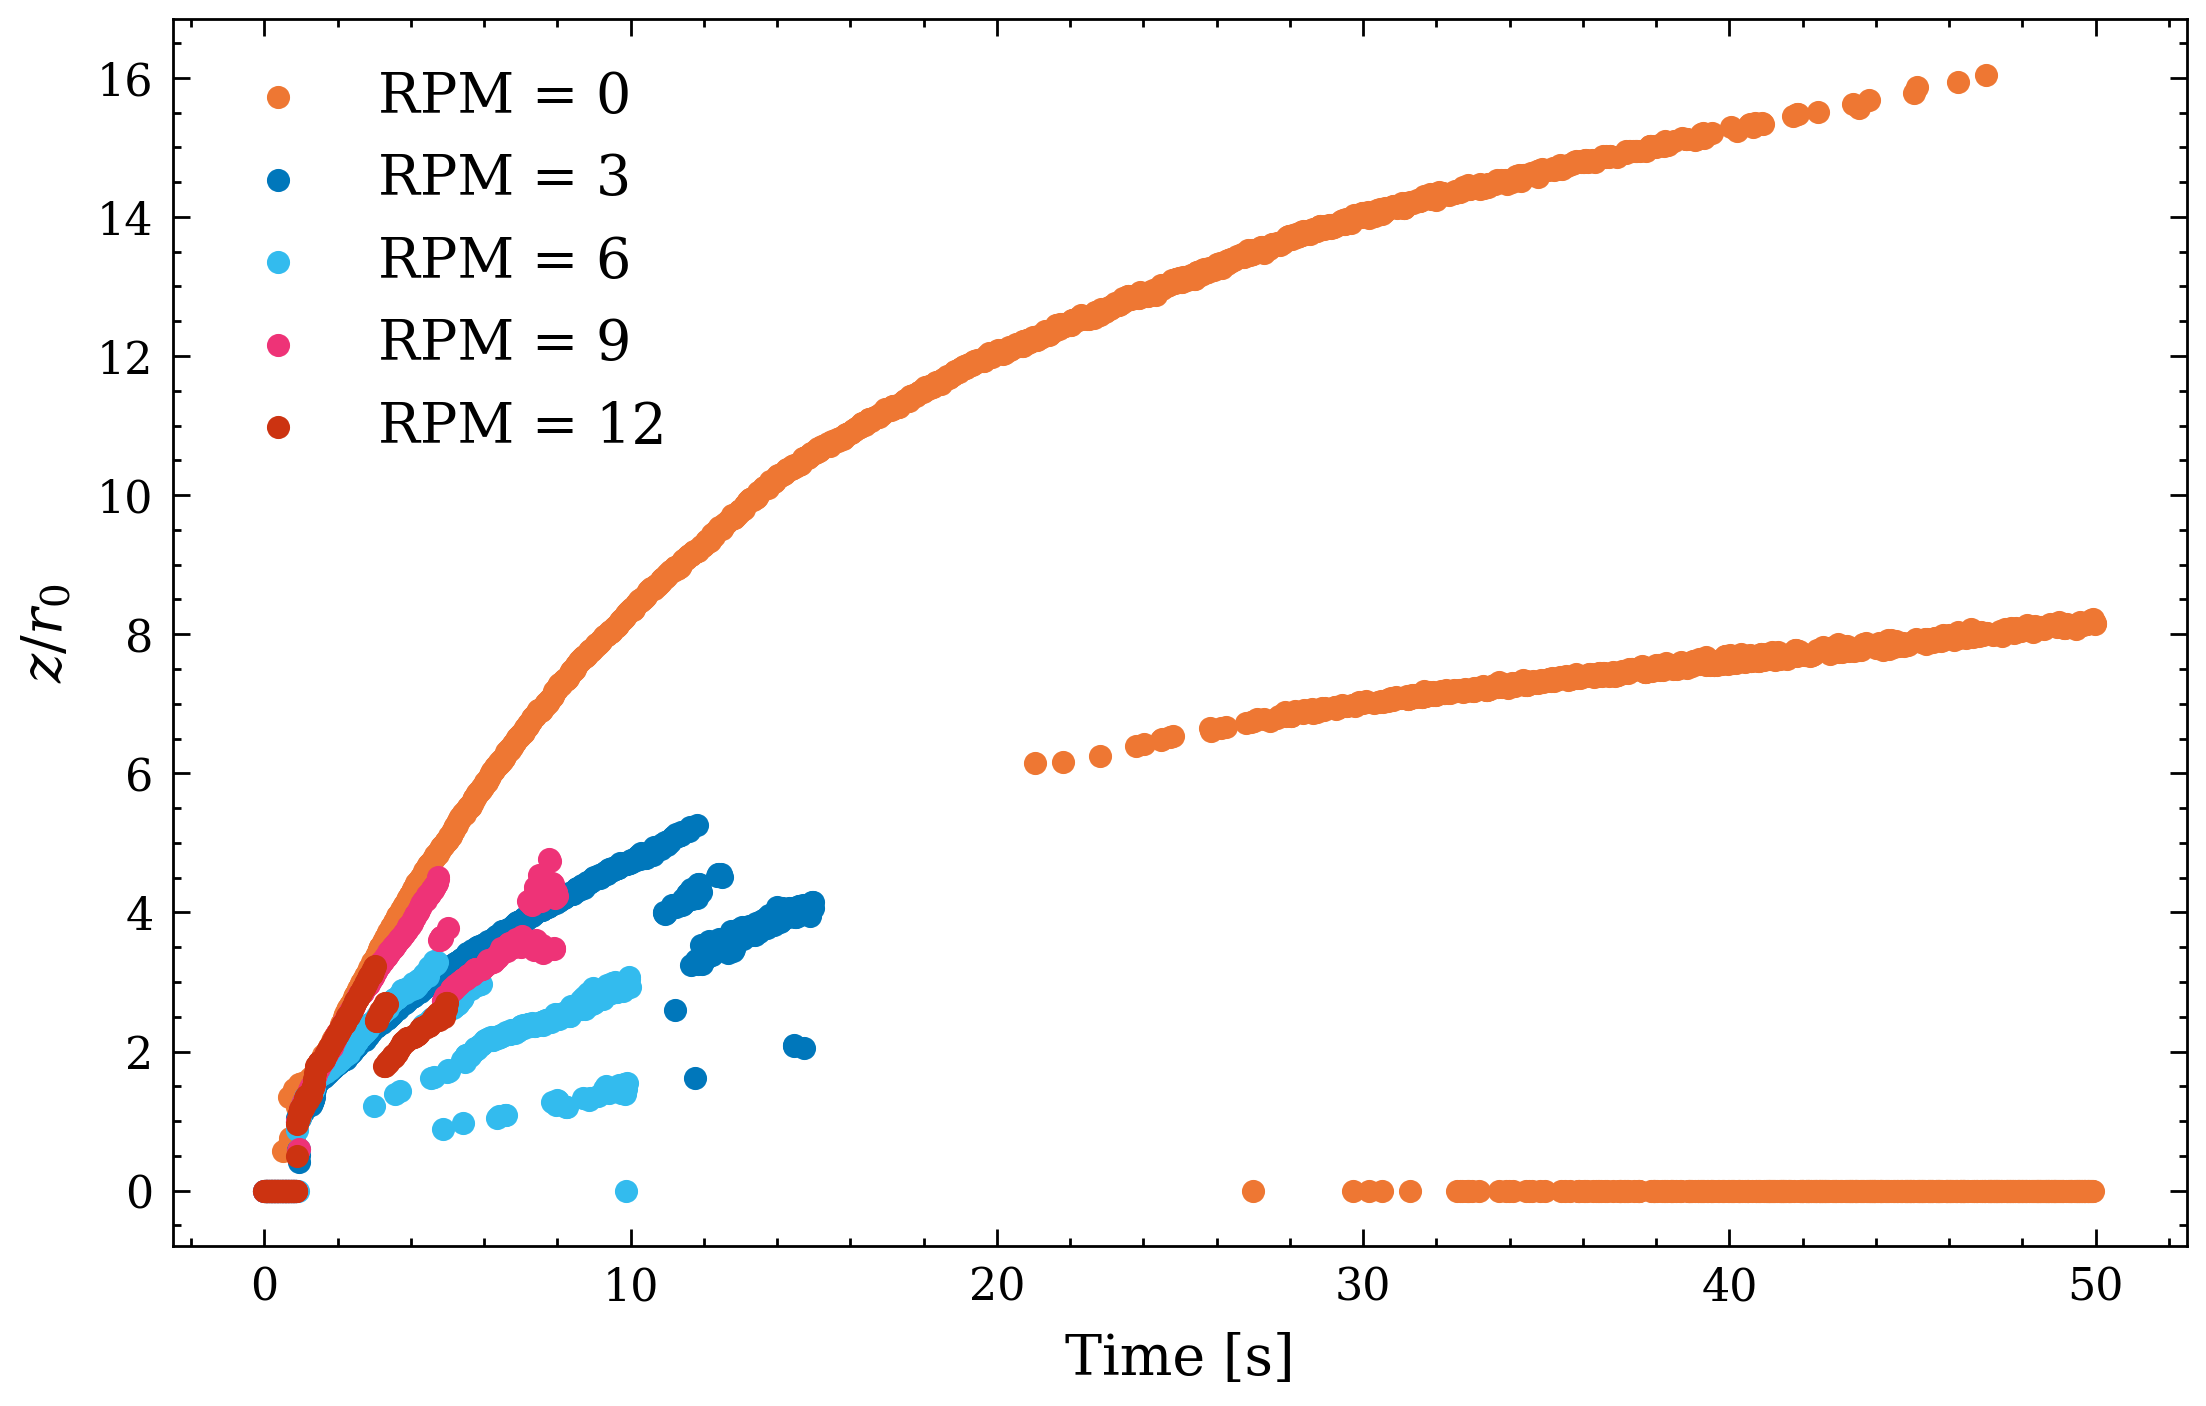

In [46]:
z_factor = u.shape[2]/(z_nd[-1])
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.scatter(Time[:3000], VortLocMean[:3000,0]/z_factor, label='RPM = 0' , s = 10)
ax.scatter(Time[:900],  VortLocMean[:900,1] /z_factor, label='RPM = 3' , s = 10)
ax.scatter(Time[:600],  VortLocMean[:600,2] /z_factor, label='RPM = 6' , s = 10)
ax.scatter(Time[:480],  VortLocMean[:480,3] /z_factor, label='RPM = 9' , s = 10)
ax.scatter(Time[:300],  VortLocMean[:300,4] /z_factor, label='RPM = 12', s = 10)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$z/r_{0}$')
ax.legend()

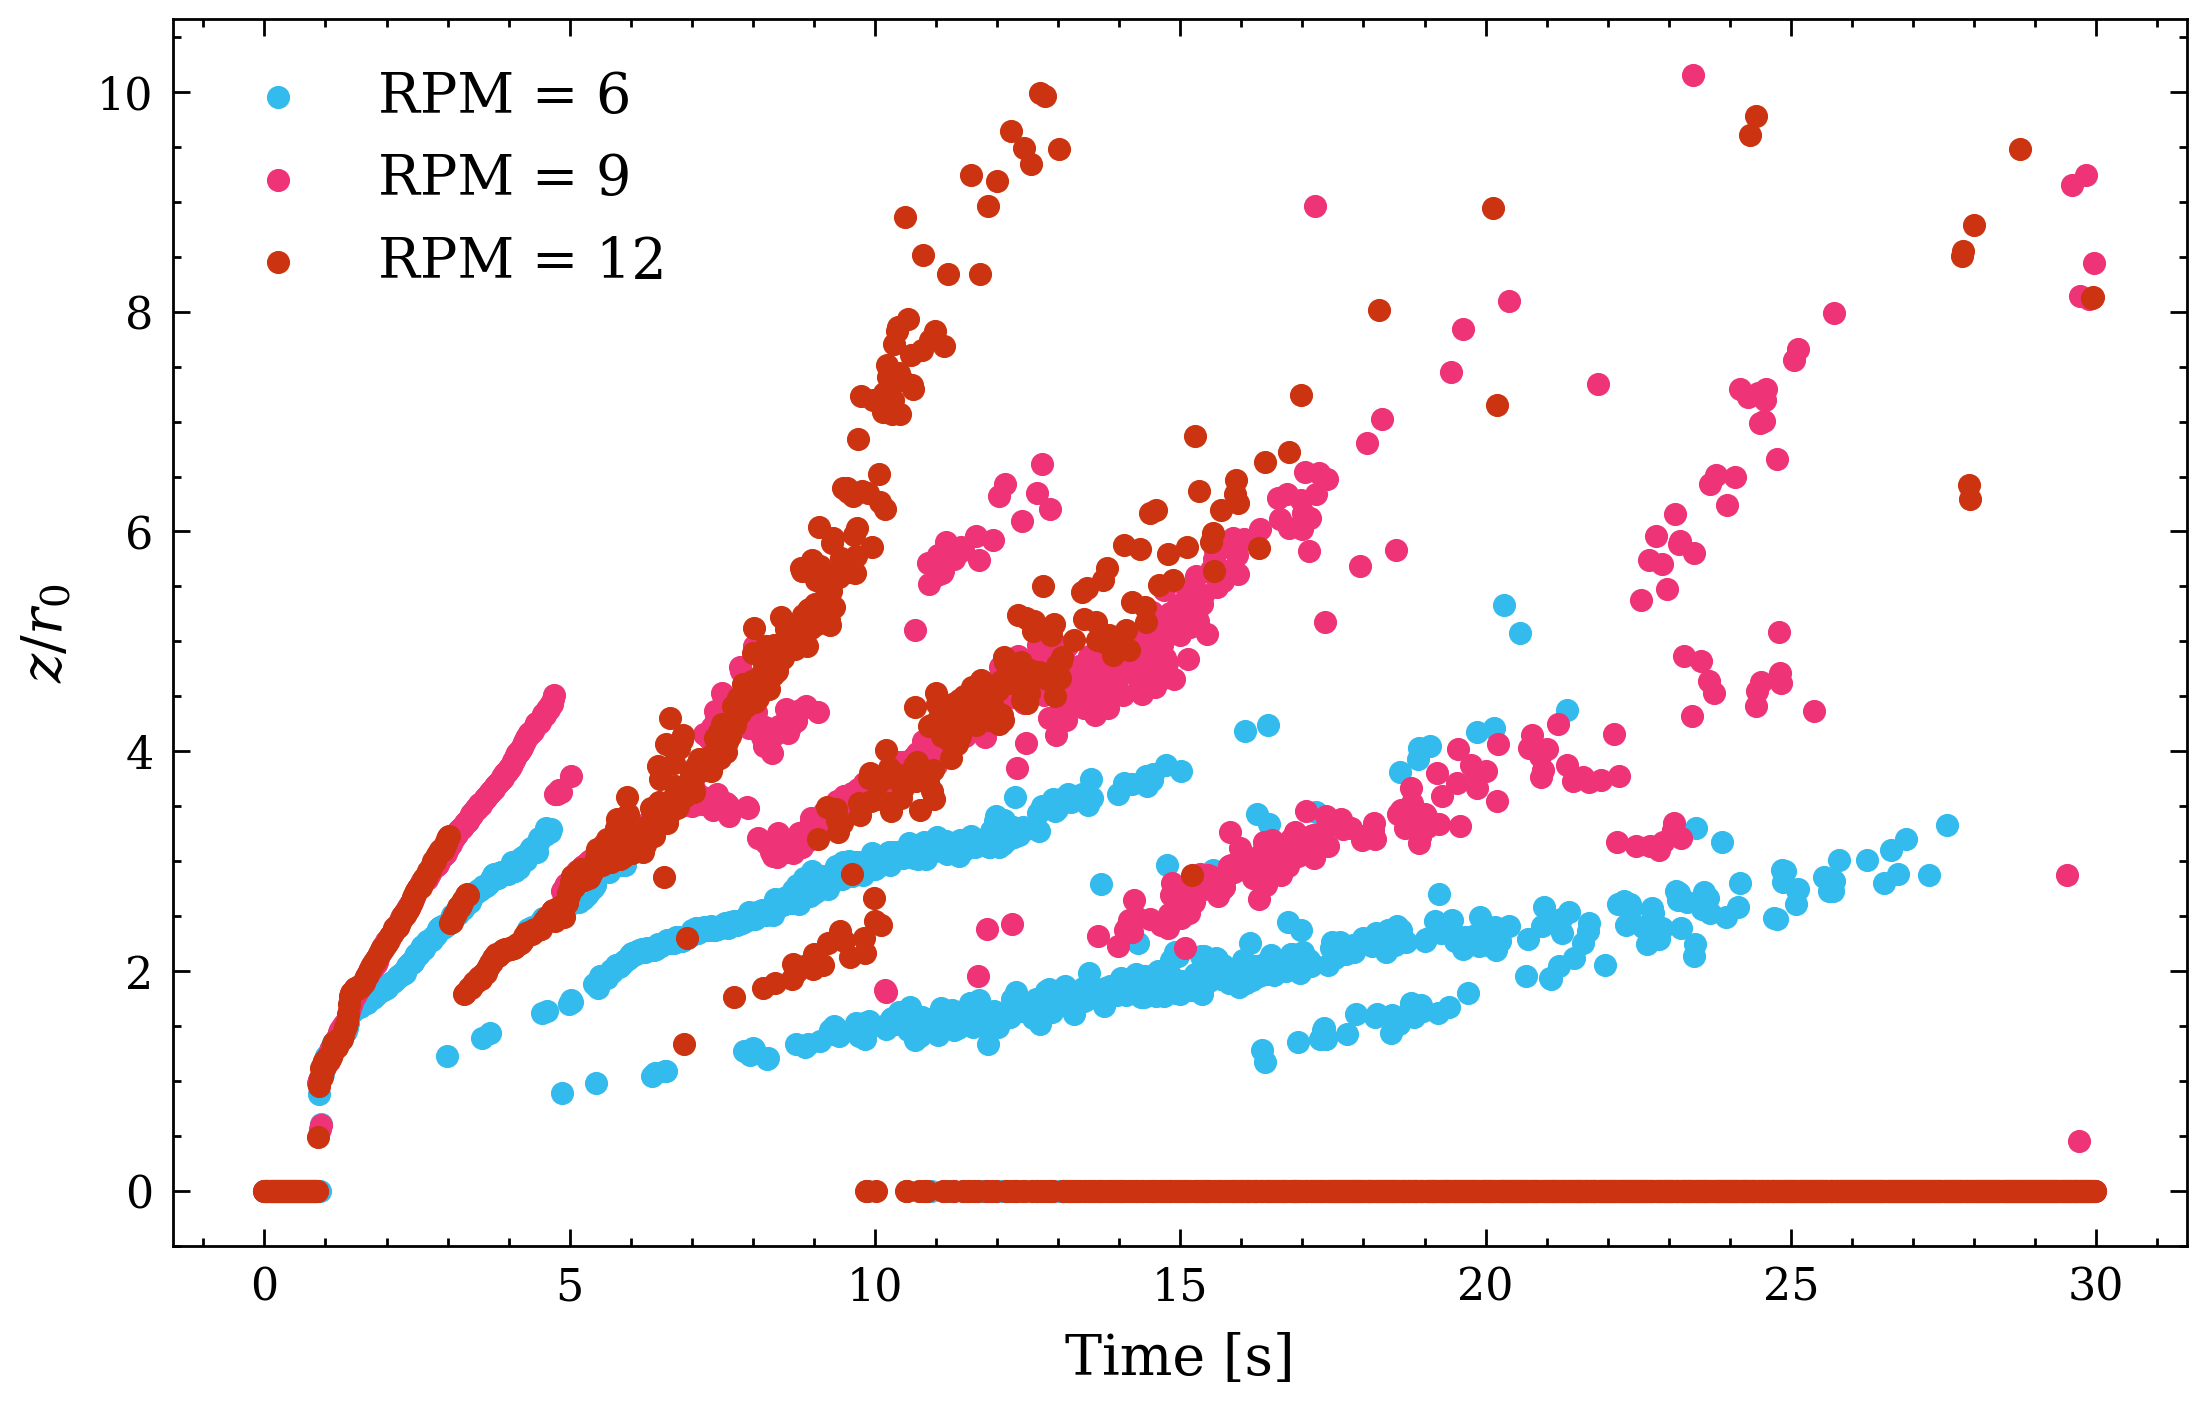

In [45]:
fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))
ax.scatter(Time[0:1], VortLocMean[0:1,0]/z_factor,  s = 0)
ax.scatter(Time[0:1],  VortLocMean[0:1,1] /z_factor,  s = 0)
ax.scatter(Time[:1800],  VortLocMean[:1800,2] /z_factor, label='RPM = 6' ,s=10,)
ax.scatter(Time[:1800],  VortLocMean[:1800,3] /z_factor, label='RPM = 9' ,s=10,)
ax.scatter(Time[:1800],  VortLocMean[:1800,4] /z_factor, label='RPM = 12',s=10,)
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$z/r_{0}$')
ax.legend()